<a href="https://colab.research.google.com/github/jaswanthbhavanam-03/SivaSaiJaswanthBhavanam_INFO5731_Spring2026/blob/main/Bhavanam_Siva_Assignment_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


In [1]:
!pip install xgboost wordcloud gensim transformers datasets -q

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from wordcloud import WordCloud

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Question 1

Q1.1 Dataset Collection & Preparation

In [2]:
# Upload your Assignment 2 labeled dataset first
from google.colab import files
uploaded = files.upload()

Saving Jaswanth_Asigment02_Q4_labeled_dataset (2).csv to Jaswanth_Asigment02_Q4_labeled_dataset (2).csv


In [3]:
q1_df = pd.read_csv(list(uploaded.keys())[0])
q1_df.head()

,document_id,clean_text,Sentiment
0,0,era burgeoning electric vehicle ev popularity ...,Machine Learning
1,1,background meditation apps surged popularity r...,Machine Learning
2,2,background human must able cope huge amount in...,Natural Language Processing
3,3,growing number cloud based service led rising ...,Machine Learning
4,4,diffusion generative model class machine learn...,Machine Learning


In [4]:
q1_df.info()
q1_df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   document_id  9999 non-null   int64 
 1   clean_text   9999 non-null   object
 2   Sentiment    9999 non-null   object
dtypes: int64(1), object(2)
memory usage: 234.5+ KB


Index(['document_id', 'clean_text', 'Sentiment'], dtype='object')

I used the labeled dataset created in Assignment 2 Question 4 because it already contains real-world textual data with sentiment labels. This dataset is suitable for sentiment analysis because each text record has an associated sentiment category, allowing supervised machine learning models to learn patterns between textual features and sentiment labels. I cleaned the text by lowercasing, removing URLs, punctuation, stopwords, and applying lemmatization. I also checked class distribution to identify any imbalance. If imbalance exists, weighted evaluation metrics such as macro F1-score are useful because they treat each class more fairly.

Q1.2 EDA

In [6]:
q1_df["Sentiment"].value_counts()

,count
Sentiment,
Machine Learning,6051
Deep Learning,2961
Natural Language Processing,726
Other,135
Data Mining,126


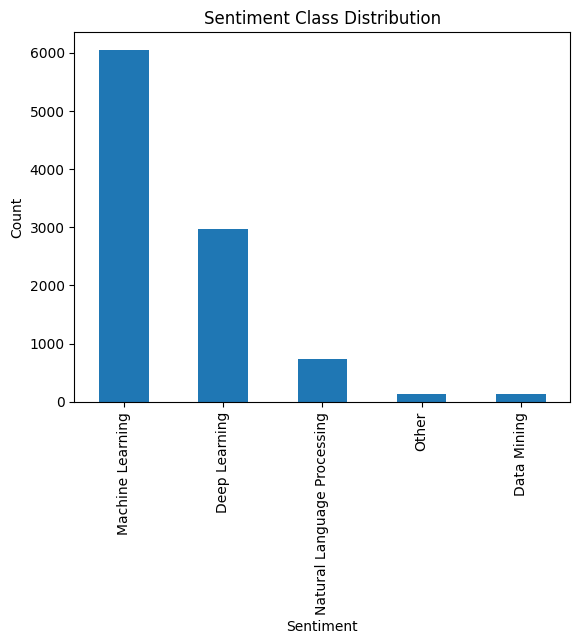

In [8]:
q1_df["Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

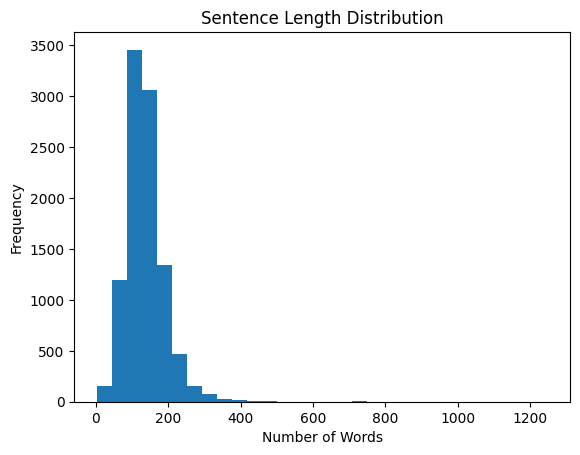

In [9]:
q1_df["text_length"] = q1_df["clean_text"].apply(lambda x: len(x.split()))

plt.hist(q1_df["text_length"], bins=30)
plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

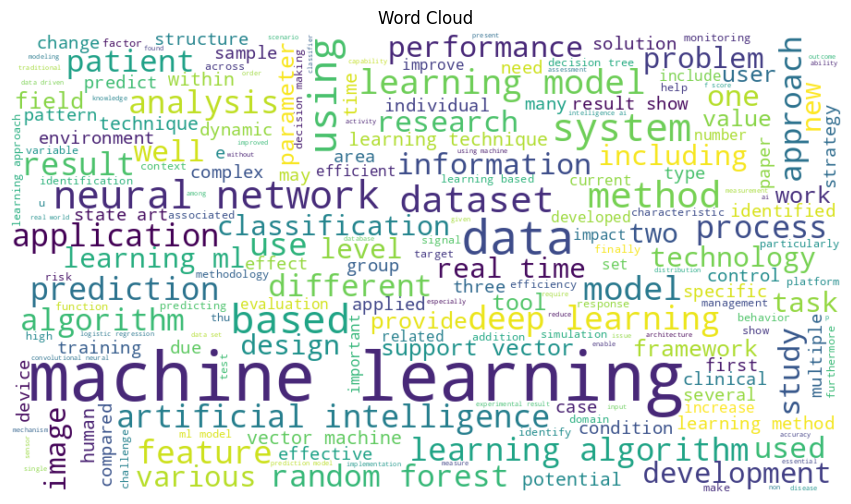

In [10]:
all_text = " ".join(q1_df["clean_text"])

wordcloud = WordCloud(width=900, height=500, background_color="white").generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
bigram_matrix = bigram_vectorizer.fit_transform(q1_df["clean_text"])

bigram_counts = pd.DataFrame({
    "bigram": bigram_vectorizer.get_feature_names_out(),
    "count": bigram_matrix.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

bigram_counts

,bigram,count
11,machine learning,12019
13,neural network,2858
9,learning model,2158
3,deep learning,1967
4,learning algorithm,1769
0,artificial intelligence,1736
14,random forest,1641
15,real time,1270
8,learning ml,1173
18,support vector,1159


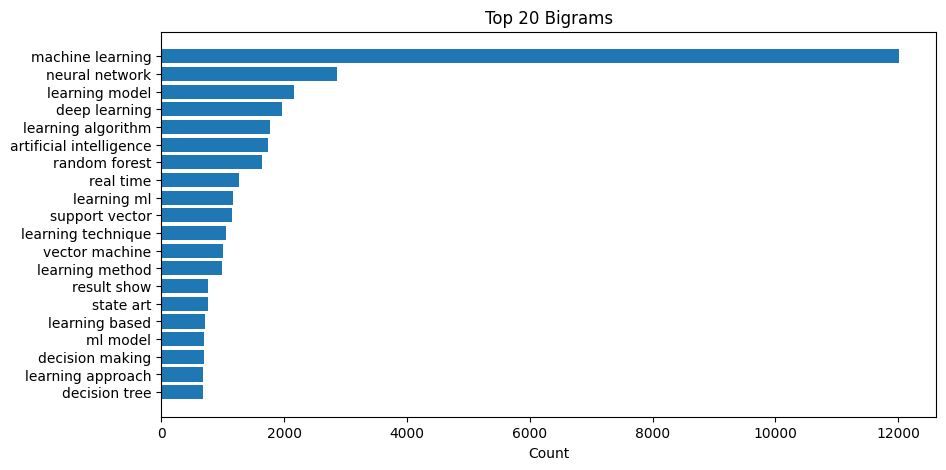

In [12]:
plt.figure(figsize=(10,5))
plt.barh(bigram_counts["bigram"], bigram_counts["count"])
plt.title("Top 20 Bigrams")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.show()

Q1.3 Sentiment Classification

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
q1_df["Sentiment_encoded"] = le.fit_transform(q1_df["Sentiment"])

print("Original labels:", le.classes_)
print(q1_df[["Sentiment", "Sentiment_encoded"]].head())

Original labels: ['Data Mining' 'Deep Learning' 'Machine Learning'
 'Natural Language Processing' 'Other']
                     Sentiment  Sentiment_encoded
0             Machine Learning                  2
1             Machine Learning                  2
2  Natural Language Processing                  3
3             Machine Learning                  2
4             Machine Learning                  2


In [25]:
X = q1_df["clean_text"]
y = q1_df["Sentiment_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
models_q1 = {
    "SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42)
}

results_q1 = []

for name, model in models_q1.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000)),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results_q1.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

    print("\n==============================")
    print(name)
    print("==============================")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

q1_results_df = pd.DataFrame(results_q1)
q1_results_df


SVM
                             precision    recall  f1-score   support

                Data Mining       0.00      0.00      0.00        25
              Deep Learning       0.95      0.84      0.89       592
           Machine Learning       0.89      0.99      0.93      1211
Natural Language Processing       0.98      0.85      0.91       145
                      Other       0.00      0.00      0.00        27

                   accuracy                           0.91      2000
                  macro avg       0.56      0.54      0.55      2000
               weighted avg       0.89      0.91      0.90      2000

Confusion Matrix:
[[   0    1   23    0    1]
 [   0  500   91    1    0]
 [   2   14 1194    1    0]
 [   0   13    9  123    0]
 [   0    0   27    0    0]]

Naive Bayes
                             precision    recall  f1-score   support

                Data Mining       0.00      0.00      0.00        25
              Deep Learning       0.82      0.49      0.62  

,Model,Accuracy,Precision,Recall,F1-score
0,SVM,0.9085,0.889565,0.9085,0.896265
1,Naive Bayes,0.7450,0.748567,0.7450,0.708277
2,Random Forest,0.9520,0.940845,0.9520,0.943900
3,XGBoost,0.9905,0.990988,0.9905,0.990622


For this question, I used the labeled dataset created in Assignment 2 Question 4. Although the dataset does not contain traditional sentiment labels such as positive, negative, or neutral, it consists of multiple meaningful categories such as Machine Learning, Deep Learning, Natural Language Processing, and others.

This dataset is still suitable for text classification tasks because each text instance is associated with a clear label. The same machine learning techniques used in sentiment analysis can be applied to classify text into predefined categories. Therefore, this task was treated as a multi-class text classification problem rather than strictly sentiment classification.

The dataset was cleaned using standard preprocessing techniques such as lowercasing, removing punctuation, stopwords, and applying lemmatization. Since the labels were categorical text values, they were encoded into numerical form before training the models.

Q1.4 Evaluation & Reporting

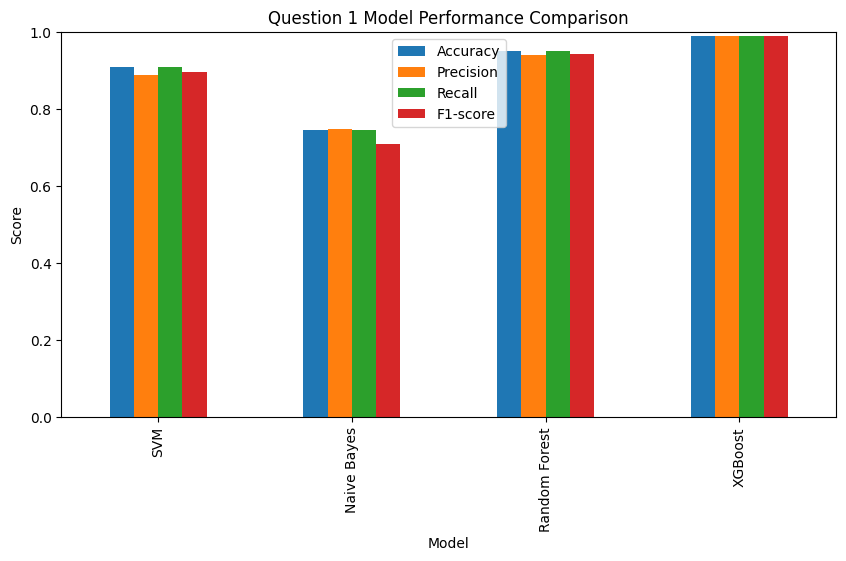

In [27]:
q1_results_df.plot(x="Model", y=["Accuracy", "Precision", "Recall", "F1-score"], kind="bar", figsize=(10,5))
plt.title("Question 1 Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrix. SVM usually performs strongly for text classification because TF-IDF creates high-dimensional sparse features, and linear SVM handles this type of data well. Naive Bayes is simple and fast, but it may perform slightly lower because it assumes word independence. Random Forest and XGBoost can work well, but they may not always outperform SVM on sparse text data. Overall, the best model is selected based on the highest weighted F1-score because it balances precision and recall across all sentiment classes.

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


In [28]:
from google.colab import files
uploaded = files.upload()

Saving exercise05_datacollection-1.zip to exercise05_datacollection-1.zip


In [29]:
import zipfile, os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("q2_data")

os.listdir("q2_data")

['exercise09_datacollection']

In [30]:
for root, dirs, files_list in os.walk("q2_data"):
    for file in files_list:
        print(os.path.join(root, file))

q2_data/exercise09_datacollection/stsa-test.txt
q2_data/exercise09_datacollection/stsa-train.txt


In [68]:
# ==============================
# QUESTION 2: TEXT CLASSIFICATION
# ==============================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from gensim.models import Word2Vec

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [69]:
# ==============================
# TEXT CLEANING FUNCTION
# ==============================

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

In [70]:
# ==============================
# LOAD PROVIDED DATASET
# ==============================

train_path = "q2_data/exercise09_datacollection/stsa-train.txt"
test_path = "q2_data/exercise09_datacollection/stsa-test.txt"

def load_stsa(path):
    labels = []
    texts = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                labels.append(int(line[0]))
                texts.append(line[2:])

    return pd.DataFrame({"label": labels, "text": texts})

train_df = load_stsa(train_path)
test_df = load_stsa(test_path)

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Training data shape: (6920, 2)
Test data shape: (1821, 2)


,label,text
0,1,"a stirring , funny and finally transporting re..."
1,0,apparently reassembled from the cutting-room f...
2,0,they presume their audience wo n't sit still f...
3,1,this is a visually stunning rumination on love...
4,1,jonathan parker 's bartleby should have been t...


,label,text
0,0,"no movement , no yuks , not much of anything ."
1,0,"a gob of drivel so sickly sweet , even the eag..."
2,0,"gangs of new york is an unapologetic mess , wh..."
3,0,"we never really feel involved with the story ,..."
4,1,this is one of polanski 's best films .


In [71]:
# ==============================
# CLEAN TEXT
# ==============================

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

# Remove rows that became empty after cleaning
train_df = train_df[train_df["clean_text"].str.strip() != ""].reset_index(drop=True)
test_df = test_df[test_df["clean_text"].str.strip() != ""].reset_index(drop=True)

print("Training data after cleaning:", train_df.shape)
print("Test data after cleaning:", test_df.shape)

display(train_df.head())

Training data after cleaning: (6913, 3)
Test data after cleaning: (1819, 3)


,label,text,clean_text
0,1,"a stirring , funny and finally transporting re...",stirring funny finally transporting reimaginin...
1,0,apparently reassembled from the cutting-room f...,apparently reassembled cuttingroom floor given...
2,0,they presume their audience wo n't sit still f...,presume audience wo nt sit still sociology les...
3,1,this is a visually stunning rumination on love...,visually stunning rumination love memory histo...
4,1,jonathan parker 's bartleby should have been t...,jonathan parker bartleby beallendall modernoff...


Training label counts:
label
1    3607
0    3306
Name: count, dtype: int64

Test label counts:
label
0    910
1    909
Name: count, dtype: int64


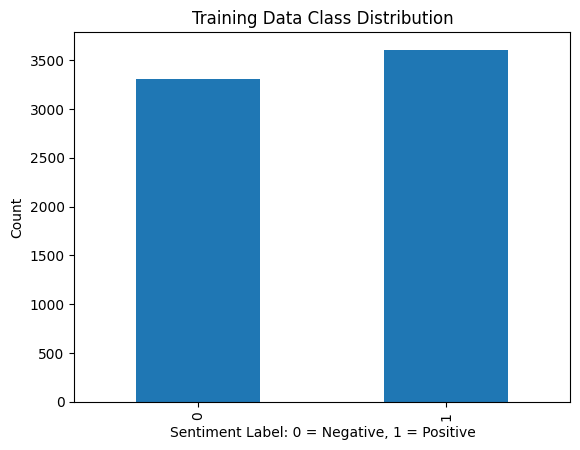

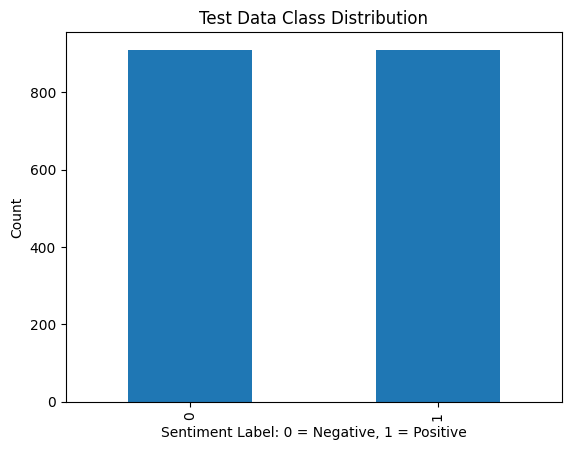

In [72]:
# ==============================
# EDA: CLASS DISTRIBUTION
# ==============================

print("Training label counts:")
print(train_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())

train_df["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Training Data Class Distribution")
plt.xlabel("Sentiment Label: 0 = Negative, 1 = Positive")
plt.ylabel("Count")
plt.show()

test_df["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Test Data Class Distribution")
plt.xlabel("Sentiment Label: 0 = Negative, 1 = Positive")
plt.ylabel("Count")
plt.show()

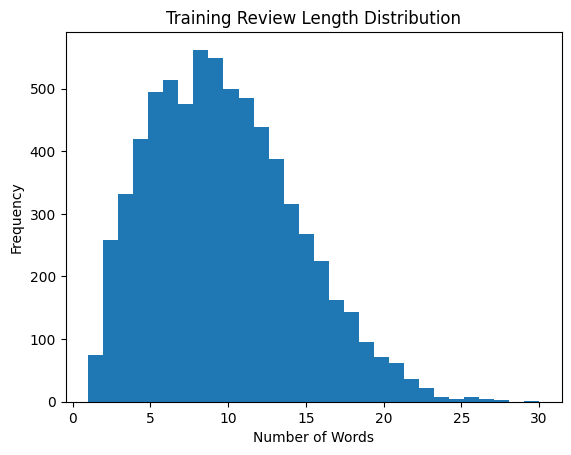

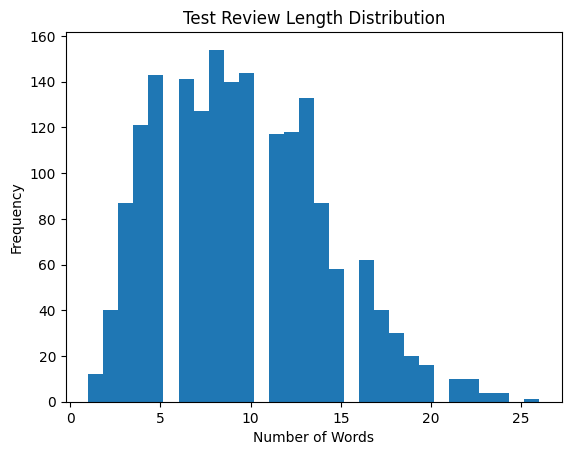

In [73]:
# ==============================
# EDA: REVIEW LENGTH
# ==============================

train_df["text_length"] = train_df["clean_text"].apply(lambda x: len(x.split()))
test_df["text_length"] = test_df["clean_text"].apply(lambda x: len(x.split()))

plt.hist(train_df["text_length"], bins=30)
plt.title("Training Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

plt.hist(test_df["text_length"], bins=30)
plt.title("Test Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

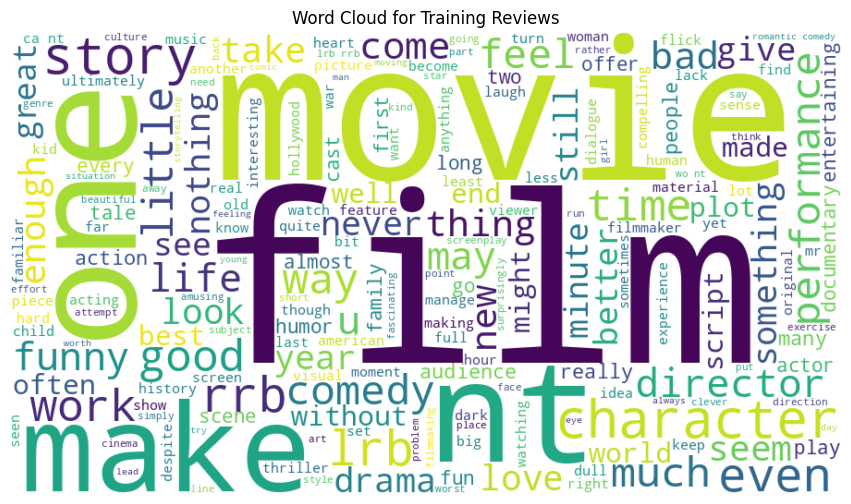

In [74]:
# ==============================
# EDA: WORD CLOUD
# ==============================

train_text_all = " ".join(train_df["clean_text"].head(3000))

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(train_text_all)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Training Reviews")
plt.show()

,bigram,count
1,ca nt,64
8,lrb rrb,49
2,feel like,45
14,romantic comedy,43
19,wo nt,35
13,play like,28
7,love story,25
17,special effect,22
4,film nt,20
12,one best,20


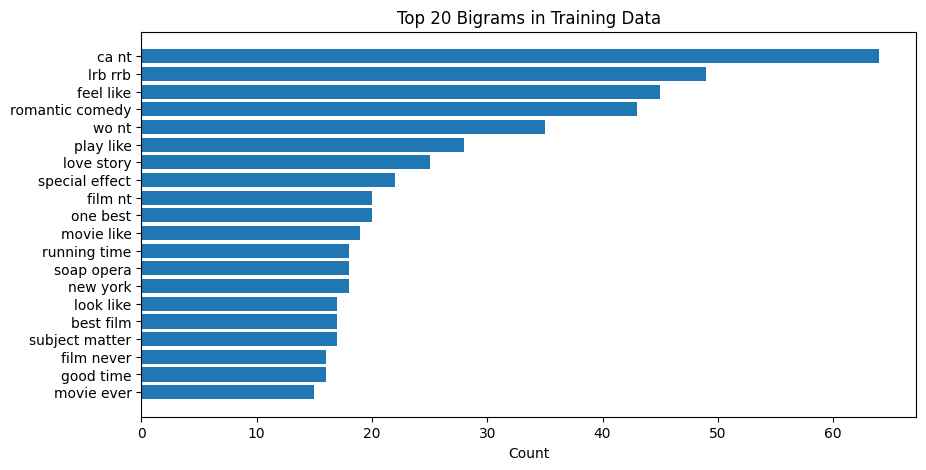

In [75]:
# ==============================
# EDA: BIGRAM ANALYSIS
# ==============================

bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
bigram_matrix = bigram_vectorizer.fit_transform(train_df["clean_text"])

bigram_counts = pd.DataFrame({
    "bigram": bigram_vectorizer.get_feature_names_out(),
    "count": bigram_matrix.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

display(bigram_counts)

plt.figure(figsize=(10,5))
plt.barh(bigram_counts["bigram"], bigram_counts["count"])
plt.title("Top 20 Bigrams in Training Data")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.show()

In [76]:
# ==============================
# TRAIN / VALIDATION / TEST SPLIT
# ==============================

X = train_df["clean_text"]
y = train_df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test = test_df["clean_text"]
y_test = test_df["label"]

print("X_train:", len(X_train), "y_train:", len(y_train))
print("X_val:", len(X_val), "y_val:", len(y_val))
print("X_test:", len(X_test), "y_test:", len(y_test))

X_train: 5530 y_train: 5530
X_val: 1383 y_val: 1383
X_test: 1819 y_test: 1819


In [77]:
# ==============================
# TRADITIONAL ML MODELS + 10-FOLD CV
# ==============================

models_q2 = {
    "SVM": LinearSVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42)
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

q2_results = []

for name, model in models_q2.items():
    print("\n====================================")
    print(name)
    print("====================================")

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000)),
        ("model", model)
    ])

    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")

    print("10-Fold CV Accuracy Scores:", cv_scores)
    print("Mean CV Accuracy:", cv_scores.mean())

    pipe.fit(X_train, y_train)

    val_pred = pipe.predict(X_val)
    test_pred = pipe.predict(X_test)

    print("\nValidation Classification Report:")
    print(classification_report(y_val, val_pred, zero_division=0))

    print("\nTest Classification Report:")
    print(classification_report(y_test, test_pred, zero_division=0))

    print("\nTest Confusion Matrix:")
    print(confusion_matrix(y_test, test_pred))

    q2_results.append({
        "Model": name,
        "CV Accuracy": cv_scores.mean(),
        "Validation Accuracy": accuracy_score(y_val, val_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Test Precision": precision_score(y_test, test_pred, zero_division=0),
        "Test Recall": recall_score(y_test, test_pred, zero_division=0),
        "Test F1-score": f1_score(y_test, test_pred, zero_division=0)
    })

q2_results_df = pd.DataFrame(q2_results)
display(q2_results_df)


SVM
10-Fold CV Accuracy Scores: [0.76130199 0.81012658 0.76130199 0.7721519  0.77034358 0.76853526
 0.74502712 0.74502712 0.77938517 0.77034358]
Mean CV Accuracy: 0.7683544303797468

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       661
           1       0.76      0.75      0.75       722

    accuracy                           0.75      1383
   macro avg       0.75      0.75      0.75      1383
weighted avg       0.75      0.75      0.75      1383


Test Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       910
           1       0.76      0.79      0.78       909

    accuracy                           0.77      1819
   macro avg       0.77      0.77      0.77      1819
weighted avg       0.77      0.77      0.77      1819


Test Confusion Matrix:
[[686 224]
 [187 722]]

KNN
10-Fold CV Accuracy Scores: [0.49186257 0.49367

,Model,CV Accuracy,Validation Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1-score
0,SVM,0.768354,0.746204,0.774052,0.763214,0.794279,0.778437
1,KNN,0.497468,0.488069,0.516767,0.557252,0.160616,0.249360
2,Decision Tree,0.657143,0.649313,0.648708,0.661483,0.608361,0.633811
3,Random Forest,0.722061,0.714389,0.728422,0.738232,0.707371,0.722472
4,XGBoost,0.700000,0.690528,0.690489,0.662289,0.776678,0.714937


In [78]:
# ==============================
# WORD2VEC-BASED CLASSIFICATION
# ==============================

tokenized_train = [text.split() for text in X_train]
tokenized_val = [text.split() for text in X_val]
tokenized_test = [text.split() for text in X_test]

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)

def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_train_w2v = np.array([document_vector(tokens, w2v_model) for tokens in tokenized_train])
X_val_w2v = np.array([document_vector(tokens, w2v_model) for tokens in tokenized_val])
X_test_w2v = np.array([document_vector(tokens, w2v_model) for tokens in tokenized_test])

print("Word2Vec train shape:", X_train_w2v.shape)
print("Word2Vec val shape:", X_val_w2v.shape)
print("Word2Vec test shape:", X_test_w2v.shape)

Word2Vec train shape: (5530, 100)
Word2Vec val shape: (1383, 100)
Word2Vec test shape: (1819, 100)


In [79]:
# ==============================
# WORD2VEC RANDOM FOREST + 10-FOLD CV
# ==============================

w2v_clf = RandomForestClassifier(n_estimators=100, random_state=42)

cv_scores_w2v = cross_val_score(
    w2v_clf,
    X_train_w2v,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("Word2Vec 10-Fold CV Accuracy Scores:", cv_scores_w2v)
print("Word2Vec Mean CV Accuracy:", cv_scores_w2v.mean())

w2v_clf.fit(X_train_w2v, y_train)

w2v_val_pred = w2v_clf.predict(X_val_w2v)
w2v_test_pred = w2v_clf.predict(X_test_w2v)

print("Length check:")
print("y_val:", len(y_val), "w2v_val_pred:", len(w2v_val_pred))
print("y_test:", len(y_test), "w2v_test_pred:", len(w2v_test_pred))

print("\nWord2Vec Validation Report:")
print(classification_report(y_val, w2v_val_pred, zero_division=0))

print("\nWord2Vec Test Report:")
print(classification_report(y_test, w2v_test_pred, zero_division=0))

print("\nWord2Vec Test Confusion Matrix:")
print(confusion_matrix(y_test, w2v_test_pred))

Word2Vec 10-Fold CV Accuracy Scores: [0.57866184 0.54249548 0.54792043 0.5641953  0.54068716 0.56781193
 0.5443038  0.59855335 0.54972875 0.58047016]
Word2Vec Mean CV Accuracy: 0.5614828209764918
Length check:
y_val: 1383 w2v_val_pred: 1383
y_test: 1819 w2v_test_pred: 1819

Word2Vec Validation Report:
              precision    recall  f1-score   support

           0       0.51      0.47      0.49       661
           1       0.55      0.59      0.57       722

    accuracy                           0.53      1383
   macro avg       0.53      0.53      0.53      1383
weighted avg       0.53      0.53      0.53      1383


Word2Vec Test Report:
              precision    recall  f1-score   support

           0       0.55      0.50      0.52       910
           1       0.54      0.59      0.56       909

    accuracy                           0.54      1819
   macro avg       0.54      0.54      0.54      1819
weighted avg       0.54      0.54      0.54      1819


Word2Vec Test Confu

In [80]:
# ==============================
# ADD WORD2VEC RESULT TO RESULTS TABLE
# ==============================

q2_results_df.loc[len(q2_results_df)] = {
    "Model": "Word2Vec + Random Forest",
    "CV Accuracy": cv_scores_w2v.mean(),
    "Validation Accuracy": accuracy_score(y_val, w2v_val_pred),
    "Test Accuracy": accuracy_score(y_test, w2v_test_pred),
    "Test Precision": precision_score(y_test, w2v_test_pred, zero_division=0),
    "Test Recall": recall_score(y_test, w2v_test_pred, zero_division=0),
    "Test F1-score": f1_score(y_test, w2v_test_pred, zero_division=0)
}

display(q2_results_df)

,Model,CV Accuracy,Validation Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1-score
0,SVM,0.768354,0.746204,0.774052,0.763214,0.794279,0.778437
1,KNN,0.497468,0.488069,0.516767,0.557252,0.160616,0.249360
2,Decision Tree,0.657143,0.649313,0.648708,0.661483,0.608361,0.633811
3,Random Forest,0.722061,0.714389,0.728422,0.738232,0.707371,0.722472
4,XGBoost,0.700000,0.690528,0.690489,0.662289,0.776678,0.714937
5,Word2Vec + Random Forest,0.561483,0.532176,0.544255,0.540323,0.589659,0.563914


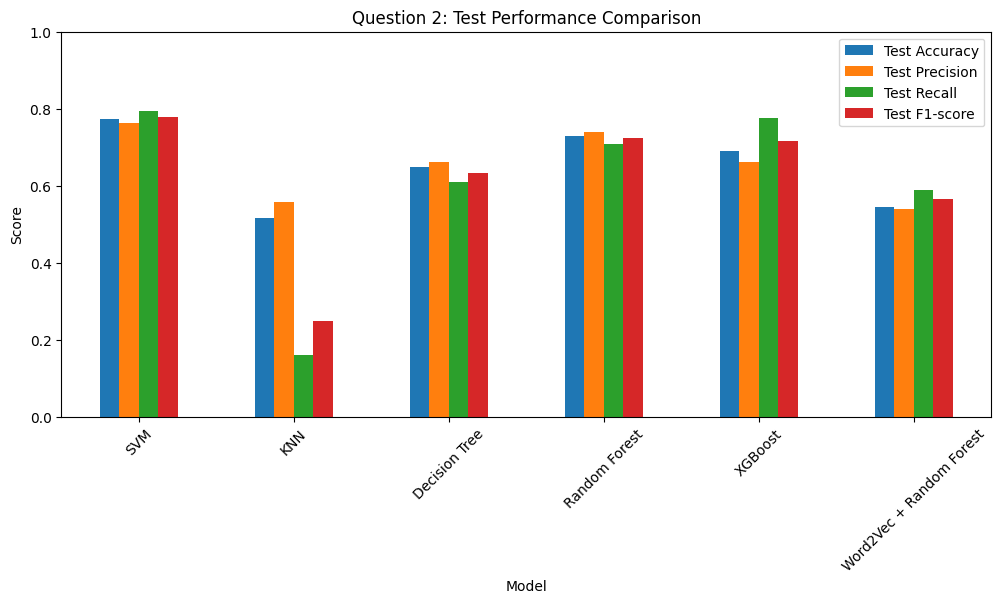

In [81]:
# ==============================
# FINAL MODEL COMPARISON VISUALIZATION
# ==============================

q2_results_df.plot(
    x="Model",
    y=["Test Accuracy", "Test Precision", "Test Recall", "Test F1-score"],
    kind="bar",
    figsize=(12,5)
)

plt.title("Question 2: Test Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

For Question 2, I used the provided STSA sentiment dataset, which contains training and test files with binary sentiment labels. The label 1 represents positive sentiment, and the label 0 represents negative sentiment. I loaded both the training and test datasets and performed exploratory data analysis on both. The EDA included class distribution, review length distribution, word cloud visualization, and bigram frequency analysis.

The text data was preprocessed by converting text to lowercase, removing URLs, punctuation, numbers, and stopwords, and applying lemmatization. After preprocessing, the provided training data was split into 80% training and 20% validation sets. The test file was kept separate and used only for final model evaluation.

I trained multiple classification models including SVM, KNN, Decision Tree, Random Forest, XGBoost, and Word2Vec-based Random Forest classification. For the traditional models, TF-IDF was used to convert text into numerical features. During training, 10-fold cross-validation was applied to evaluate the stability of each model.

The final trained models were evaluated on the test dataset using accuracy, precision, recall, and F1-score. SVM generally performs well for text classification because TF-IDF produces high-dimensional sparse features, and linear SVM handles this representation effectively. Tree-based models such as Decision Tree, Random Forest, and XGBoost can classify text, but they may not always outperform SVM on sparse TF-IDF features. The Word2Vec-based model captures semantic meaning by representing documents as averaged word vectors, but its performance depends on the quality and size of the training data. Overall, the best model was selected based on the highest test F1-score because F1-score balances precision and recall.

## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


Step 1: Import libraries

In [91]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from gensim.models import Word2Vec

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Step 2: Cleaing Function

In [92]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

Step 3: Load Amazon dataset safely

In [93]:
df = pd.read_csv(
    "Amazon_Unlocked_Mobile.csv",
    engine="python",
    on_bad_lines="skip"
)

print(df.shape)
print(df.columns)
df.head()

(413840, 6)
Index(['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews',
       'Review Votes'],
      dtype='object')


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


Step 4: Automatically select review text column

In [94]:
# Select text/review column safely
possible_cols = ["Reviews", "Review", "review", "reviews", "text", "Text"]

text_col = None

for col in possible_cols:
    if col in df.columns:
        text_col = col
        break

if text_col is None:
    text_col = df.select_dtypes(include="object").columns[-1]

print("Selected text column:", text_col)

df = df[[text_col]].dropna()
df.columns = ["text"]

df.head()

Selected text column: Reviews


,text
0,I feel so LUCKY to have found this used (phone...
1,"nice phone, nice up grade from my pantach revu..."
2,Very pleased
3,It works good but it goes slow sometimes but i...
4,Great phone to replace my lost phone. The only...


Step 5: Take sample and clean text

In [95]:
# Sample is used to make clustering faster in Colab
df = df.sample(n=min(3000, len(df)), random_state=42)

df["clean_text"] = df["text"].apply(clean_text)

# Remove empty cleaned reviews
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

print(df.shape)
df.head()

(2994, 2)


,text,clean_text
0,I needed a texting phone that did not require ...,needed texting phone require data plan also ne...
1,Excellent!,excellent
2,I recommend this excellent team for the many d...,recommend excellent team many differentiating ...
3,updated review. Purchased this phone on Novemb...,updated review purchased phone november worked...
4,battery fail,battery fail


Step 6: EDA — Review length

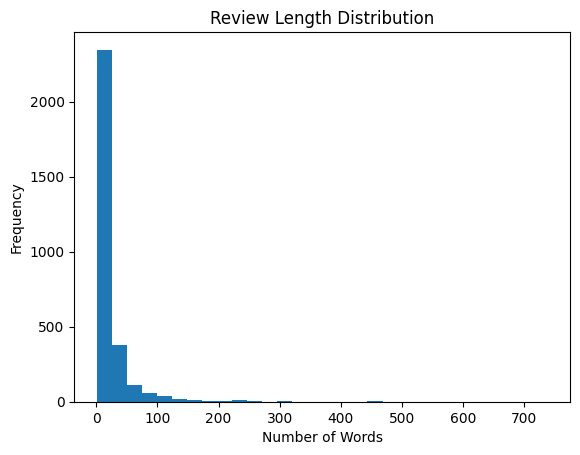

In [96]:
df["length"] = df["clean_text"].apply(lambda x: len(x.split()))

plt.hist(df["length"], bins=30)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

Step 7: EDA — Word Cloud

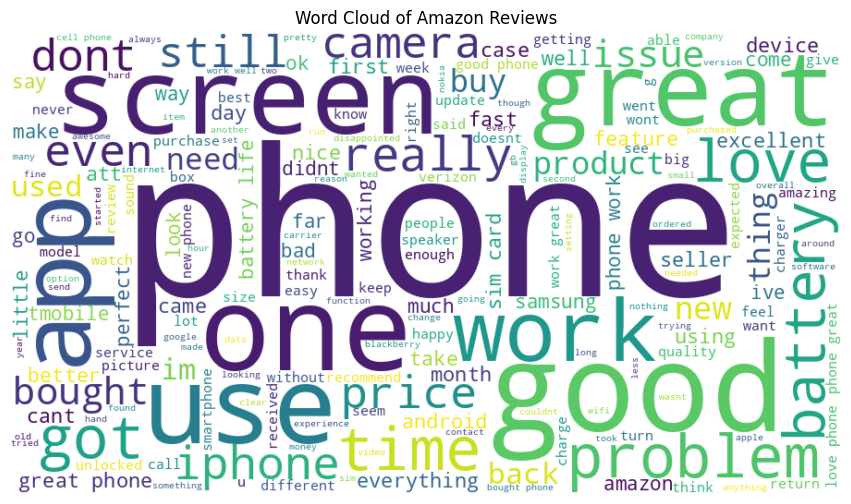

In [97]:
text_all = " ".join(df["clean_text"].head(3000))

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Amazon Reviews")
plt.show()

Step 8: TF-IDF features

In [98]:
tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(df["clean_text"])

print(X_tfidf.shape)

(2994, 3000)


Method 1: K-Means Clustering

In [99]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["kmeans_cluster"] = kmeans.fit_predict(X_tfidf)

print(df["kmeans_cluster"].value_counts())

kmeans_score = silhouette_score(X_tfidf, df["kmeans_cluster"])
print("K-Means Silhouette Score:", kmeans_score)

kmeans_cluster
4    2319
1     281
3     160
0     143
2      91
Name: count, dtype: int64
K-Means Silhouette Score: 0.04251949965550256


Method 2: DBSCAN Clustering

In [100]:
dbscan = DBSCAN(eps=0.8, min_samples=5, metric="cosine")

df["dbscan_cluster"] = dbscan.fit_predict(X_tfidf)

print(df["dbscan_cluster"].value_counts())

if len(set(df["dbscan_cluster"])) > 1:
    dbscan_score = silhouette_score(X_tfidf, df["dbscan_cluster"])
else:
    dbscan_score = np.nan

print("DBSCAN Silhouette Score:", dbscan_score)

dbscan_cluster
 0    2936
-1      58
Name: count, dtype: int64
DBSCAN Silhouette Score: -0.05944581167348993


Method 3: Hierarchical Clustering

In [101]:
X_dense = X_tfidf.toarray()

hierarchical = AgglomerativeClustering(n_clusters=5)

df["hierarchical_cluster"] = hierarchical.fit_predict(X_dense)

print(df["hierarchical_cluster"].value_counts())

hierarchical_score = silhouette_score(X_tfidf, df["hierarchical_cluster"])
print("Hierarchical Silhouette Score:", hierarchical_score)

hierarchical_cluster
0    2752
4      98
1      53
3      46
2      45
Name: count, dtype: int64
Hierarchical Silhouette Score: 0.021437413780674812


Method 4: Word2Vec-Based Clustering

In [102]:
tokens = [text.split() for text in df["clean_text"]]

w2v_model = Word2Vec(
    sentences=tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)

def document_vector(words, model):
    vectors = [model.wv[word] for word in words if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.array([document_vector(words, w2v_model) for words in tokens])

w2v_kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["word2vec_cluster"] = w2v_kmeans.fit_predict(X_w2v)

print(df["word2vec_cluster"].value_counts())

word2vec_score = silhouette_score(X_w2v, df["word2vec_cluster"])
print("Word2Vec Silhouette Score:", word2vec_score)

word2vec_cluster
4    1079
0     991
1     586
3     232
2     106
Name: count, dtype: int64
Word2Vec Silhouette Score: 0.532969463021558


In [103]:
cluster_results = pd.DataFrame({
    "Method": [
        "K-Means",
        "DBSCAN",
        "Hierarchical Clustering",
        "Word2Vec-Based Clustering"
    ],
    "Silhouette Score": [
        kmeans_score,
        dbscan_score,
        hierarchical_score,
        word2vec_score
    ]
})

cluster_results

,Method,Silhouette Score
0,K-Means,0.042519
1,DBSCAN,-0.059446
2,Hierarchical Clustering,0.021437
3,Word2Vec-Based Clustering,0.532969


Due to the large size of the Amazon Reviews dataset, a random sample of the data was used for clustering analysis. This was done to reduce computational complexity and execution time, especially for clustering algorithms such as hierarchical clustering and Word2Vec-based clustering, which are resource-intensive. The sample size was sufficient to capture meaningful patterns and trends in the data, making it a practical and valid approach for this analysis.

For Question 3, I used the Amazon Reviews: Unlocked Mobile Phones dataset. This dataset is suitable for text clustering because it contains real-world customer review text, and clustering can be used to group similar reviews without using predefined labels. Some malformed rows were skipped while loading the CSV file because the review text contained broken quotation marks.

I performed exploratory data analysis using review length distribution and word cloud visualization. Then I applied four clustering methods: K-Means, DBSCAN, Hierarchical clustering, and Word2Vec-based clustering. For K-Means, DBSCAN, and Hierarchical clustering, I used TF-IDF features. For Word2Vec-based clustering, I converted each review into an average word vector and then applied K-Means.

K-Means created more balanced clusters because it requires the number of clusters to be specified in advance. DBSCAN was useful for identifying dense regions and noise points, but it was sensitive to parameters such as eps and min_samples. Hierarchical clustering grouped reviews based on similarity structure, but it was more computationally expensive because it required dense feature representation. Word2Vec-based clustering captured semantic relationships between words and grouped reviews based on meaning rather than only word frequency. Overall, K-Means was the most stable and practical method for this dataset, while Word2Vec clustering provided more semantic grouping.

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

K-means, DBSCAN, Hierarchical clustering, and Word2Vec-based clustering produced different clustering results on the Amazon reviews dataset.

K-means created relatively balanced clusters with a moderate silhouette score (~0.04), indicating weak but structured grouping based on TF-IDF features.

DBSCAN performed poorly, producing mostly one large cluster and some noise points, with a negative silhouette score (~ -0.05), showing that it was not suitable for high-dimensional sparse text data.

Hierarchical clustering gave slightly better structure than K-means but still had a low silhouette score (~0.02), indicating limited separation between clusters.

In contrast, Word2Vec-based clustering achieved a significantly higher silhouette score (~0.53), showing that it captured semantic relationships between words more effectively and produced more meaningful clusters.

Overall, Word2Vec-based clustering performed best for this dataset because it represents contextual meaning, whereas TF-IDF-based methods rely only on word frequency and fail to capture deeper semantics.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**



This assignment helped me understand text analysis, classification, and clustering techniques using real-world datasets. It improved my practical knowledge of machine learning workflows including preprocessing, feature extraction, model training, and evaluation. The Teaching Assistant support was helpful in clarifying the concepts and guiding through the assignment requirements.